In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
path = "drive/MyDrive/"
data = pd.read_csv("Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [3]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


One problem with salary prediction is that it's oddly distributed: there are many people who are paid standard salaries and a few that get tons o money. The distribution is fat-tailed on the right side, which is inconvenient for MSE minimization.

There are several techniques to combat this: using a different loss function, predicting log-target instead of raw target or even replacing targets with their percentiles among all salaries in the training set. We gonna use logarithm for now.

_You can read more [in the official description](https://www.kaggle.com/c/job-salary-prediction#description)._

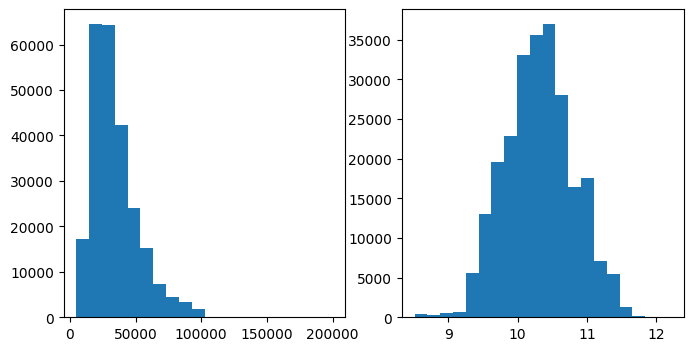

In [4]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

In [5]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
10486,66386696,Customer Service Representative (Norwegian),We are currently recruiting for a Norwegian sp...,Belfast,Belfast,NaN,permanent,Teletech,IT Jobs,12500 - 15000,13750,Multilingualvacancies,9.528867
24566,67652783,IT Support Analyst,Our client is looking for a Support Analyst in...,"Kingston upon Thames, Surrey",UK,NaN,permanent,Huntress Group,IT Jobs,16000 - 21000/annum,18500,cv-library.co.uk,9.825580
10963,66501073,Carer Development Workers,LCPT Leicestershire Community Projects Trust C...,Leicestershire,Leicestershire,full_time,contract,LEICESTERSHIRE COMMUNITY PROJECT TRUST,Charity & Voluntary Jobs,"NJC 25: 21,519 (pro rata for part-time)",10772,jobs.guardian.co.uk,9.284799


In [6]:
def data_string_token(data_string):
  return ' '.join(tokenizer.tokenize(str(data_string))).lower()  # we use str(data_string) to tokenize None objects as well as valid strings

In [7]:
import nltk
#TODO YOUR CODE HERE

tokenizer = nltk.tokenize.WordPunctTokenizer()
# YOUR CODE HERE
data["Title"] = data["Title"].apply(data_string_token)
data["FullDescription"] = data["FullDescription"].apply(data_string_token)


In [8]:
from collections import Counter
token_counts = Counter()

# Count how many times does each token occur in both "Title" and "FullDescription" in total
#TODO <YOUR CODE>
for title in data["Title"]:
  token_counts.update(title.split())

for desc in data["FullDescription"]:
  token_counts.update(desc.split())


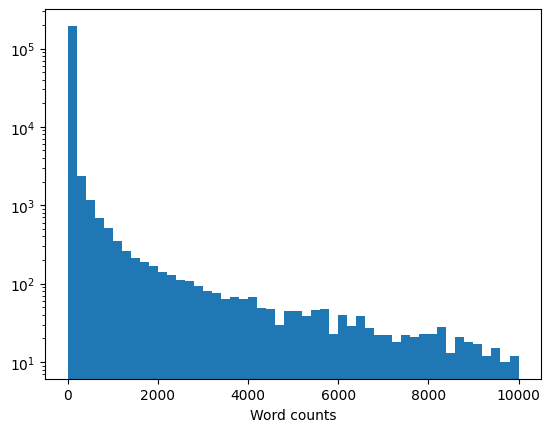

In [9]:
# Let's see how many words are there for each count
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts");

__Task 1.1__ Get a list of all tokens that occur at least 10 times.

In [10]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = sorted(token for token, count in token_counts.items() if count >= min_count)#TODO<YOUR CODE HERE>

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [11]:
print("Vocabulary size:", len(tokens))
assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens
print("Correct!")

Vocabulary size: 34158
Correct!


__Task 1.2__ Build an inverse token index: a dictionary from token(string) to it's index in `tokens` (int)

In [12]:
token_to_id = {}  #<your code here - dict of token name to its index in tokens>
for index, token in enumerate(tokens):
  if token not in token_to_id:
    token_to_id[token] = index


In [13]:
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok

print("Correct!")

Correct!


And finally, let's use the vocabulary you've built to map text lines into neural network-digestible matrices.

In [14]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [15]:
print("Lines:")
print('\n'.join(data["Title"][::100000].values), end='\n\n')
print("Matrix:")
print(as_matrix(data["Title"][::100000]))

Lines:
engineering systems analyst
hr assistant
senior ec & i engineer

Matrix:
[[10807 30161  2166     1     1]
 [15020  2844     1     1     1]
 [27645 10201    16 15215 10804]]


Now let's  encode the categirical data we have.

As usual, we shall use one-hot encoding for simplicity. Kudos if you implement more advanced encodings: tf-idf, pseudo-time-series, etc.

In [16]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

,dtype,<class 'numpy.float32'>
,separator,'='
,sparse,False
,sort,True


### The deep learning part

Once we've learned to tokenize the data, let's design a machine learning experiment.

As before, we won't focus too much on validation, opting for a simple train-test split.

__To be completely rigorous,__ we've comitted a small crime here: we used the whole data for tokenization and vocabulary building. A more strict way would be to do that part on training set only. You may want to do that and measure the magnitude of changes.

In [17]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


device = 'cuda' if torch.cuda.is_available() else 'cpu'


def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [19]:
make_batch(data_train[:3], max_len=10)

{'Title': tensor([[27645, 29893, 33674,     1,     1,     1,     1],
         [29239,   197, 19175, 20042, 15554, 23162,  4051],
         [10609, 30412, 17746,    33,  8705, 29157,    65]], device='cuda:0'),
 'FullDescription': tensor([[27645, 29893, 33674, 32939,   982, 27645, 29893, 33674, 16451, 32939],
         [29239,   197, 19175, 20042, 15554, 23162,  4051, 25511,   907,    82],
         [30746, 21956, 20601,  6409, 16451,  8165, 27493,   982, 30412, 17746]],
        device='cuda:0'),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144], device='cuda:0')}

#### Architecture

Our basic model consists of three branches:
* Title encoder
* Description encoder
* Categorical features encoder

We will then feed all 3 branches into one common network that predicts salary.

![scheme](https://github.com/yandexdataschool/nlp_course/raw/master/resources/w2_conv_arch.png)

In [20]:
class Permute(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = dims

    def forward(self, x):
        x = x.permute(self.dims)
        return x
    

class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #  YOUR CODE HERE
        self.enc = nn.Sequential(
            nn.Embedding(n_tokens, 32),
            Permute(dims=[0, 2, 1]),
            nn.Conv1d(32, hid_size, kernel_size=3)
        )
        self.linear = nn.Linear(n_cat_features, hid_size)

        self.fc = nn.Sequential(
            nn.Linear(3 * hid_size, hid_size),
            nn.Linear(hid_size, 1)
        )


    def forward(self, batch):
        title_enc = self.enc(batch["Title"])
        max_pool_title = torch.max(title_enc, dim=-1).values

        desc_enc = self.enc(batch["FullDescription"])
        max_pool_descr = torch.max(desc_enc, dim=-1).values

        cat_feat = self.linear(batch["Categorical"])

        combined = torch.cat([max_pool_title, max_pool_descr, cat_feat], dim=1)

        return self.fc(combined).squeeze(-1)







#### Training and evaluation

As usual, we gonna feed our monster with random minibatches of data.

As we train, we want to monitor not only loss function, which is computed in log-space, but also the actual error measured in dollars.

In [21]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch

        if not cycle: break

### Model training

We can now fit our model the usual minibatch way. The interesting part is that we train on an infinite stream of minibatches, produced by `iterate_minibatches` function.

In [22]:
from tqdm.auto import tqdm

BATCH_SIZE = 32
EPOCHS = 200

c:\Users\salni\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    #print("%s results:" % (name or ""))
    #print("Mean square error: %.5f" % mse)
    #print("Mean absolute error: %.5f" % mae)
    return mse, mae


In [26]:
import pickle

def training_cycle(model, learning_rate=1e-04, num_epochs=EPOCHS):
  model_name = str(f"{model}".split('(')[0])
  model = model.to(device)
  criterion = nn.MSELoss(reduction='sum')
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  history = {'MAE':[], 'MSE': []}
  #early_stopping = EarlyStopping()
  emae0, emse0 = 0, 0
  
  for epoch in tqdm(range(num_epochs)):
      #print(f"epoch: {epoch}")
      model.train()
      for i, batch in enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)):
          pred = model(batch)
          loss = criterion(pred, batch[TARGET_COLUMN])
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      emse, emae = print_metrics(model, data_val, device=device)
      #early_stopping(emse0, emse)
      #if early_stopping.early_stop:
        #print("We are at epoch:", i)
        #break
      emse0, emae0 = emse, emae
      history['MAE'].append(emae)
      history['MSE'].append(emse)

  # Save to file
  with open(f'{model_name}_mae_hist', 'wb') as file:
    pickle.dump(history, file)


  plt.plot(history['MAE'], label='MAE', color='blue')
  plt.plot(history['MSE'], label='MSE', color='red')
  #plt.plot([0, 1], [0, 1], '--', color='black',)
  plt.legend(fontsize='large')
  plt.xlabel("epoch")
  plt.grid()
  plt.title(f"{model_name} MAE history")
  plt.show()

100%|██████████| 15/15 [13:27<00:00, 53.80s/it]


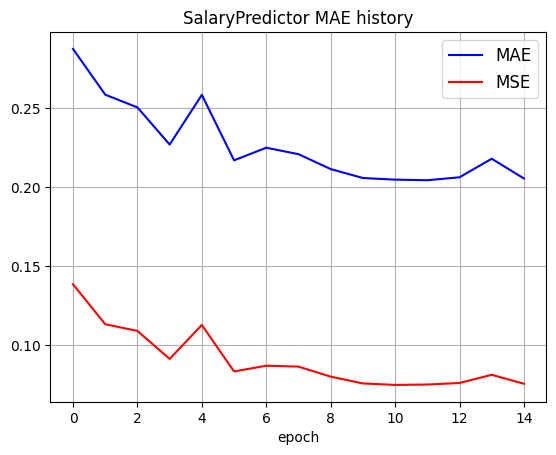

In [28]:
training_cycle(SalaryPredictor(), num_epochs=15)

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...

In [29]:
class SalaryPredictor_A(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #self.hid_size = hid_size

        # Shared embedding layer
        self.embedding = nn.Embedding(n_tokens, 32)

        # Parallel convolution layers with different kernel sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=2, padding=1),  # for bigrams
            nn.BatchNorm1d(hid_size // 4),

        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=3, padding=1),  # for trigrams
            nn.BatchNorm1d(hid_size // 4),

        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=4, padding=2),  # for 4-grams
            nn.BatchNorm1d(hid_size // 4),

        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=5, padding=2),  # for 5-grams
            nn.BatchNorm1d(hid_size // 4),

        )

        self.linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.BatchNorm1d(hid_size),

        )

        self.fc = nn.Sequential(
            nn.Linear(2 * hid_size + (hid_size // 4) * 4, hid_size),  # Adjusted for concatenated conv outputs
            #nn.BatchNorm1d(hid_size),
            nn.Dropout(0.2),
            nn.Linear(hid_size, 1)
        )

    def forward(self, batch):
        # Process Title
        title_emb = self.embedding(batch["Title"])
        title_emb = title_emb.permute(0, 2, 1)  # [batch, channels, seq_len]

        # Apply parallel convolutions to title
        title_conv1 = self.conv1(title_emb)
        title_conv2 = self.conv2(title_emb)
        title_conv3 = self.conv3(title_emb)
        title_conv4 = self.conv4(title_emb)

        # Max pooling and concatenate
        title_pool1 = torch.max(title_conv1, dim=-1).values
        title_pool2 = torch.max(title_conv2, dim=-1).values
        title_pool3 = torch.max(title_conv3, dim=-1).values
        title_pool4 = torch.max(title_conv4, dim=-1).values

        title_combined = torch.cat([title_pool1, title_pool2, title_pool3, title_pool4], dim=1)

        # Process FullDescription
        desc_emb = self.embedding(batch["FullDescription"])
        desc_emb = desc_emb.permute(0, 2, 1)  # [batch, channels, seq_len]

        # Apply parallel convolutions to description
        desc_conv1 = self.conv1(desc_emb)
        desc_conv2 = self.conv2(desc_emb)
        desc_conv3 = self.conv3(desc_emb)
        desc_conv4 = self.conv4(desc_emb)

        # Max pooling and concatenate
        desc_pool1 = torch.max(desc_conv1, dim=-1).values
        desc_pool2 = torch.max(desc_conv2, dim=-1).values
        desc_pool3 = torch.max(desc_conv3, dim=-1).values
        desc_pool4 = torch.max(desc_conv4, dim=-1).values

        desc_combined = torch.cat([desc_pool1, desc_pool2, desc_pool3, desc_pool4], dim=1)

        # Process categorical features
        cat_feat = self.linear(batch["Categorical"])

        # Combine all features
        combined = torch.cat([title_combined, desc_combined, cat_feat], dim=1)
        return self.fc(combined).squeeze(-1)

100%|██████████| 15/15 [26:50<00:00, 107.39s/it]


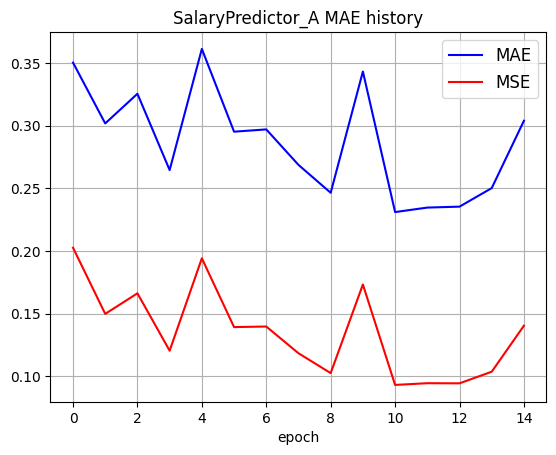

In [30]:
training_cycle(SalaryPredictor_A(), num_epochs=15)

#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

In [31]:
class SalaryPredictor_B(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #self.hid_size = hid_size

        # Shared embedding layer
        self.embedding = nn.Embedding(n_tokens, 32)

        # Parallel convolution layers with different kernel sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=2, padding=1),  # for bigrams
            nn.BatchNorm1d(hid_size // 4),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(),
            nn.Softmax(dim=1),

        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=3, padding=1),  # for trigrams
            nn.BatchNorm1d(hid_size // 4),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(),
            nn.Softmax(dim=1),

        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=4, padding=2),  # for 4-grams
            nn.BatchNorm1d(hid_size // 4),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(),
            nn.Softmax(dim=1),

        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=5, padding=2),  # for 5-grams
            nn.BatchNorm1d(hid_size // 4),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(),
            nn.Softmax(dim=1),

        )

        self.linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.BatchNorm1d(hid_size),
            nn.Dropout(),

        )

        self.fc = nn.Sequential(
            nn.Linear(2 * hid_size + (hid_size // 4) * 4, 5 * hid_size),  # Adjusted for concatenated conv outputs
            nn.Dropout(0.2),
            
            nn.Linear(5 * hid_size, 3 * hid_size),  # Adjusted for concatenated conv outputs
            nn.Dropout(0.2),
            
            nn.Linear(3 * hid_size, hid_size),  # Adjusted for concatenated conv outputs
            nn.Softmax(dim=1),
            nn.Dropout(0.2),
            
            
            nn.Linear(hid_size, 1)
        )

    def forward(self, batch):
        # Process Title
        title_emb = self.embedding(batch["Title"])
        title_emb = title_emb.permute(0, 2, 1)  # [batch, channels, seq_len]

        # Apply parallel convolutions to title
        title_conv1 = self.conv1(title_emb)
        title_conv2 = self.conv2(title_emb)
        title_conv3 = self.conv3(title_emb)
        title_conv4 = self.conv4(title_emb)

        # Max pooling and concatenate
        title_pool1 = torch.max(title_conv1, dim=-1).values
        title_pool2 = torch.max(title_conv2, dim=-1).values
        title_pool3 = torch.max(title_conv3, dim=-1).values
        title_pool4 = torch.max(title_conv4, dim=-1).values

        title_combined = torch.cat([title_pool1, title_pool2, title_pool3, title_pool4], dim=1)

        # Process FullDescription
        desc_emb = self.embedding(batch["FullDescription"])
        desc_emb = desc_emb.permute(0, 2, 1)  # [batch, channels, seq_len]

        # Apply parallel convolutions to description
        desc_conv1 = self.conv1(desc_emb)
        desc_conv2 = self.conv2(desc_emb)
        desc_conv3 = self.conv3(desc_emb)
        desc_conv4 = self.conv4(desc_emb)

        # Max pooling and concatenate
        desc_pool1 = torch.max(desc_conv1, dim=-1).values
        desc_pool2 = torch.max(desc_conv2, dim=-1).values
        desc_pool3 = torch.max(desc_conv3, dim=-1).values
        desc_pool4 = torch.max(desc_conv4, dim=-1).values

        desc_combined = torch.cat([desc_pool1, desc_pool2, desc_pool3, desc_pool4], dim=1)

        # Process categorical features
        cat_feat = self.linear(batch["Categorical"])

        # Combine all features
        combined = torch.cat([title_combined, desc_combined, cat_feat], dim=1)
        return self.fc(combined).squeeze(-1)

In [ ]:
torch.cuda.is_available()

False

100%|██████████| 15/15 [44:06<00:00, 176.46s/it]


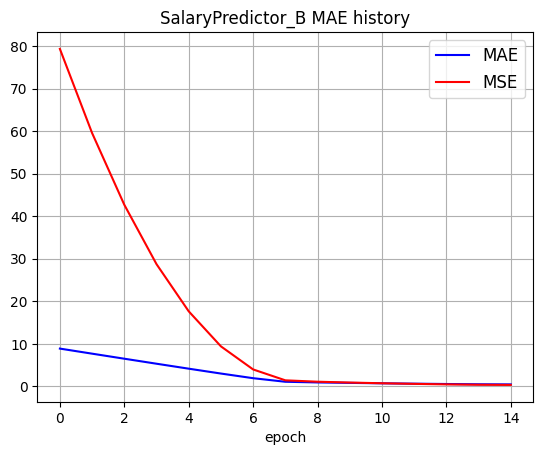

In [32]:
training_cycle(SalaryPredictor_B(), num_epochs=15)

#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea

In [33]:
class EarlyStopping:
    def __init__(self, tolerance=5, min_delta=0.01):

        self.tolerance = tolerance
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, last, this):
        if np.abs(last - this) < self.min_delta:
            self.counter +=1
            if self.counter >= self.tolerance:  
                self.early_stop = True
                
                


In [34]:
def training_cycle_E(model, learning_rate=1e-04, num_epochs=EPOCHS):
  model_name = str(f"{model}".split('(')[0])
  model = model.to(device)
  criterion = nn.MSELoss(reduction='sum')
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  history = {'MAE':[], 'MSE': []}
  early_stopping = EarlyStopping()
  emae0, emse0 = 0, 0
  
  for epoch in tqdm(range(num_epochs)):
      #print(f"epoch: {epoch}")
      model.train()
      for i, batch in enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)):
          pred = model(batch)
          loss = criterion(pred, batch[TARGET_COLUMN])
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      emse, emae = print_metrics(model, data_val, device=device)
      early_stopping(emse0, emse)
      if early_stopping.early_stop:
        print("We are at epoch:", epoch)
        break
      emse0, emae0 = emse, emae
      history['MAE'].append(emae)
      history['MSE'].append(emse)

  # Save to file
  with open(f'{model_name}_mae_hist', 'wb') as file:
    pickle.dump(history, file)


  plt.plot(history['MAE'], label='MAE', color='blue')
  plt.plot(history['MSE'], label='MSE', color='red')
  #plt.plot([0, 1], [0, 1], '--', color='black',)
  plt.legend(fontsize='large')
  plt.xlabel("epoch")
  plt.grid()
  plt.title(f"{model_name} MAE history")
  plt.show()

 11%|█         | 22/200 [40:41<5:29:12, 110.97s/it]

We are at epoch: 22


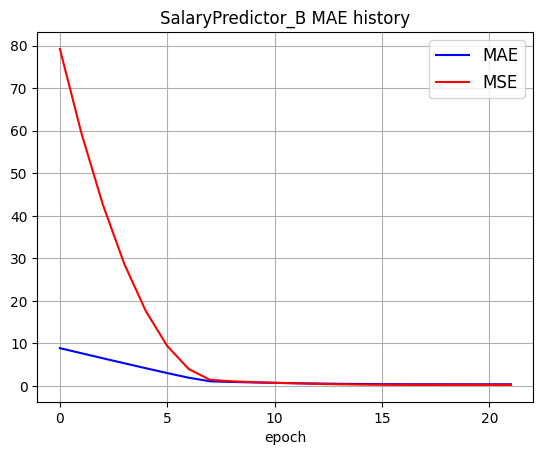

In [37]:
training_cycle_E(SalaryPredictor_B())

### Bonus part: explaining model predictions

It's usually a good idea to understand how your model works before you let it make actual decisions. It's simple for linear models: just see which words learned positive or negative weights. However, its much harder for neural networks that learn complex nonlinear dependencies.

There are, however, some ways to look inside the black box:
* Seeing how model responds to input perturbations
* Finding inputs that maximize/minimize activation of some chosen neurons (_read more [on distill.pub](https://distill.pub/2018/building-blocks/)_)
* Building local linear approximations to your neural network: [article](https://arxiv.org/abs/1602.04938), [eli5 library](https://github.com/TeamHG-Memex/eli5/tree/master/eli5/formatters)

Today we gonna try the first method just because it's the simplest one.

In [ ]:
def explain(model, sample, col_name='Title'):
    """ Computes the effect each word had on model predictions """
    sample = dict(sample)
    sample_col_tokens = [tokens[token_to_id.get(tok, 0)] for tok in sample[col_name].split()]
    data_drop_one_token = pd.DataFrame([sample] * (len(sample_col_tokens) + 1))

    for drop_i in range(len(sample_col_tokens)):
        data_drop_one_token.loc[drop_i, col_name] = ' '.join(UNK if i == drop_i else tok
                                                   for i, tok in enumerate(sample_col_tokens))

    *predictions_drop_one_token, baseline_pred = model(make_batch(data_drop_one_token, device=device)).detach().cpu()
    diffs = baseline_pred - torch.Tensor(predictions_drop_one_token)
    return list(zip(sample_col_tokens, diffs))

In [ ]:
from IPython.display import HTML, display_html


def draw_html(tokens_and_weights, cmap=plt.get_cmap("bwr"), display=True,
              token_template="""<span style="background-color: {color_hex}">{token}</span>""",
              font_style="font-size:14px;"
             ):

    def get_color_hex(weight):
        rgba = cmap(1. / (1 + np.exp(float(weight))), bytes=True)
        return '#%02X%02X%02X' % rgba[:3]

    tokens_html = [
        token_template.format(token=token, color_hex=get_color_hex(weight))
        for token, weight in tokens_and_weights
    ]


    raw_html = """<p style="{}">{}</p>""".format(font_style, ' '.join(tokens_html))
    if display:
        display_html(HTML(raw_html))

    return raw_html


In [ ]:
i = 36605
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

In [ ]:
i = 12077
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

In [ ]:
i = np.random.randint(len(data))
print("Index:", i)
print("Salary (gbp):", np.expm1(model(make_batch(data.iloc[i: i+1], device=device)).detach().cpu()))

tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

__Terrible start-up idea #1962:__ make a tool that automaticaly rephrases your job description (or CV) to meet salary expectations :)